# Restaurant Wait Time & Customer Satisfaction Analysis

## Business Problem

The goal of this project was to identify operational conditions associated with declining customer satisfaction in a restaurant environment, particularly during periods of increased demand and promotional activity.

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [68]:
df= pd.read_csv('restaurant_wait_time_project_dataset.csv')

## Data Overview

This dataset contains restaurant operational snapshots, including guest counts, staffing levels, wait times, table turn time, promotional activity, complaints, revenue, and customer satisfaction.

In [69]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   2500 non-null   object 
 1   day_of_week            2500 non-null   object 
 2   hour                   2500 non-null   int64  
 3   meal_period            2500 non-null   object 
 4   weather                2500 non-null   object 
 5   promo_active           2500 non-null   int64  
 6   guests                 2500 non-null   int64  
 7   servers_on_shift       2500 non-null   int64  
 8   kitchen_staff          2500 non-null   int64  
 9   wait_time_minutes      2500 non-null   float64
 10  table_turn_time        2500 non-null   float64
 11  avg_ticket             2500 non-null   float64
 12  revenue                2500 non-null   float64
 13  customer_satisfaction  2500 non-null   float64
 14  complaints             2500 non-null   int64  
dtypes: f

,0
date,0
day_of_week,0
hour,0
meal_period,0
weather,0
promo_active,0
guests,0
servers_on_shift,0
kitchen_staff,0
wait_time_minutes,0


In [70]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
date,2500,180,2025-01-24,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day_of_week,2500,7,Sunday,362,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hour,2500.0,NaN,NaN,NaN,16.1884,3.501572,11.0,13.0,17.0,19.0,21.0
meal_period,2500,2,Dinner,1404,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weather,2500,3,Sunny,1292,NaN,NaN,NaN,NaN,NaN,NaN,NaN
promo_active,2500.0,NaN,NaN,NaN,0.35,0.477065,0.0,0.0,0.0,1.0,1.0
guests,2500.0,NaN,NaN,NaN,39.1372,11.84132,8.0,31.0,39.0,47.0,76.0
servers_on_shift,2500.0,NaN,NaN,NaN,6.12,2.086946,3.0,5.0,6.0,8.0,14.0
kitchen_staff,2500.0,NaN,NaN,NaN,3.0208,1.105647,2.0,2.0,3.0,4.0,8.0
wait_time_minutes,2500.0,NaN,NaN,NaN,23.54536,5.662136,5.2,19.6,23.45,27.4,46.3


In [71]:
#The dataset includes lunch and dinner service periods, with  records for the 15:00–16:00 transition window.

df['hour'].value_counts().sort_index()


,count
hour,
11,262
12,289
13,278
14,267
17,258
18,273
19,293
20,278
21,302


In [72]:
df['date'] = pd.to_datetime(df['date'])

## Univariate Analysis

Wait times appear relatively concentrated around the 20–25 minute range, with limited extreme outliers. The average wait time during the operational snapshot was approximately 23 minutes, suggesting the restaurant typically operates with moderate but consistent service delays.

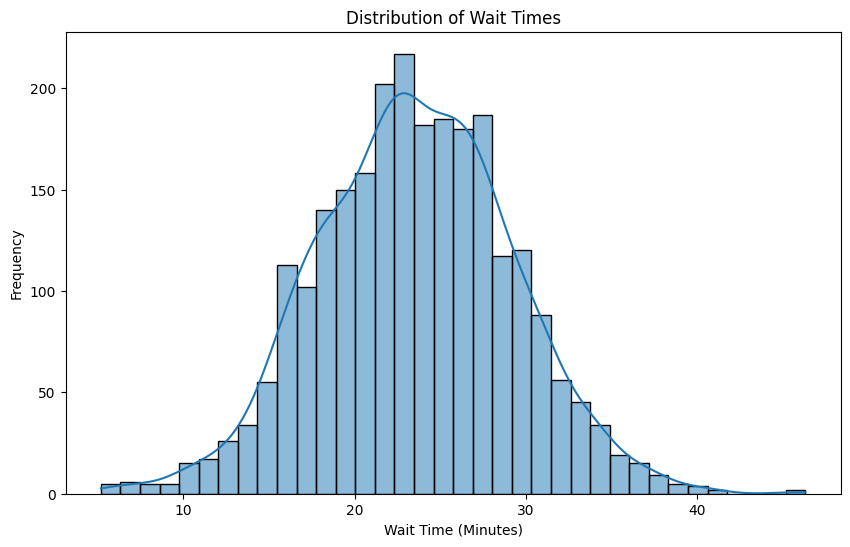

In [73]:
plt.figure(figsize=(10,6))

sns.histplot(df['wait_time_minutes'], kde=True)

plt.title('Distribution of Wait Times')
plt.xlabel('Wait Time (Minutes)')
plt.ylabel('Frequency')

plt.show()

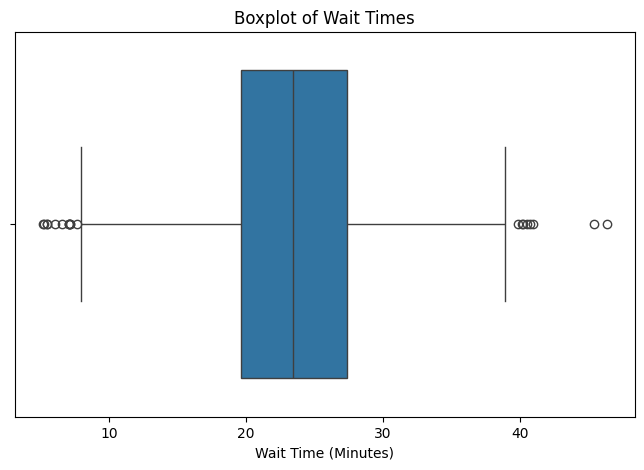

In [74]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['wait_time_minutes'])

plt.title('Boxplot of Wait Times')
plt.xlabel('Wait Time (Minutes)')

plt.show()

Average ticket values were relatively concentrated around the restaurant’s mean spend level, suggesting consistent guest spending behavior across most operational periods. The restaurant’s moderate average ticket price may also contribute to relatively stable customer satisfaction despite operational inefficiencies.

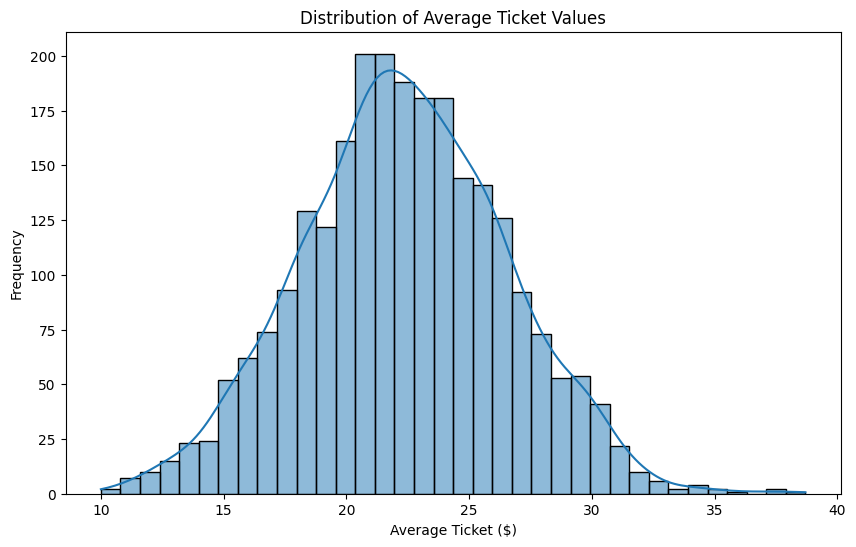

In [75]:
plt.figure(figsize=(10,6))

sns.histplot(df['avg_ticket'], kde=True);

plt.title('Distribution of Average Ticket Values')
plt.xlabel('Average Ticket ($)')
plt.ylabel('Frequency');

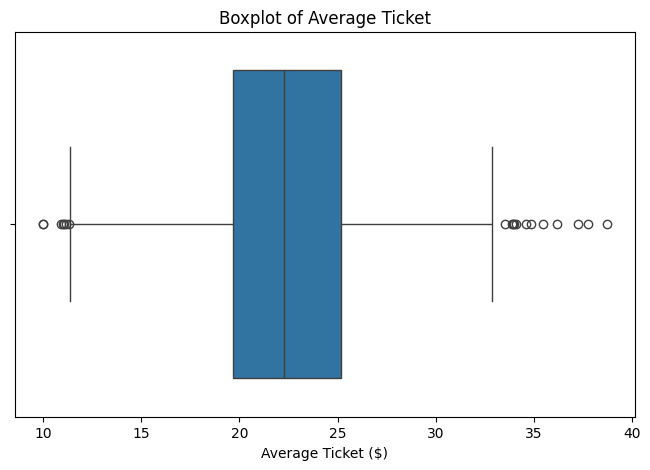

In [76]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['avg_ticket'])

plt.title('Boxplot of Average Ticket')
plt.xlabel('Average Ticket ($)');

Average table turn times were concentrated around the restaurant’s mean operational range, suggesting relatively consistent table occupancy durations throughout service periods. Later analysis identified longer table turn times as potentially associated with lower customer satisfaction and increased operational strain.

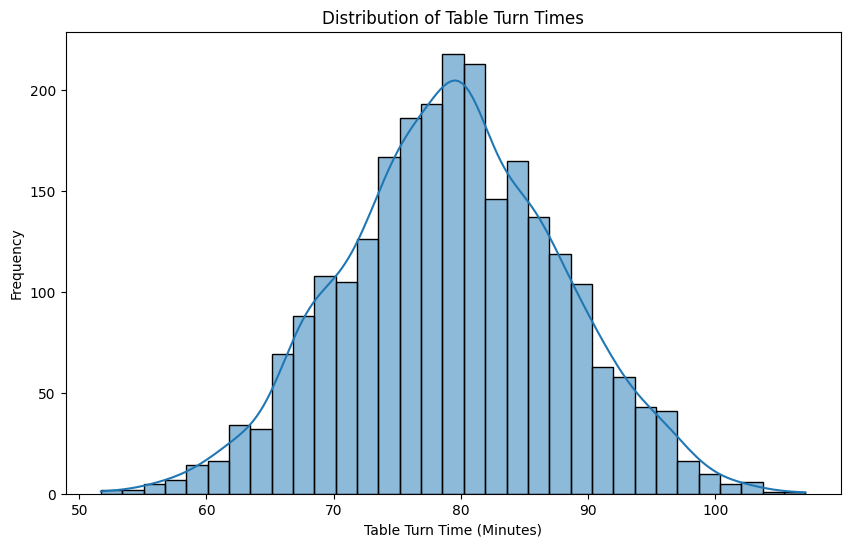

In [77]:
plt.figure(figsize=(10,6))

sns.histplot(df['table_turn_time'], kde=True);

plt.title('Distribution of Table Turn Times')
plt.xlabel('Table Turn Time (Minutes)')
plt.ylabel('Frequency');

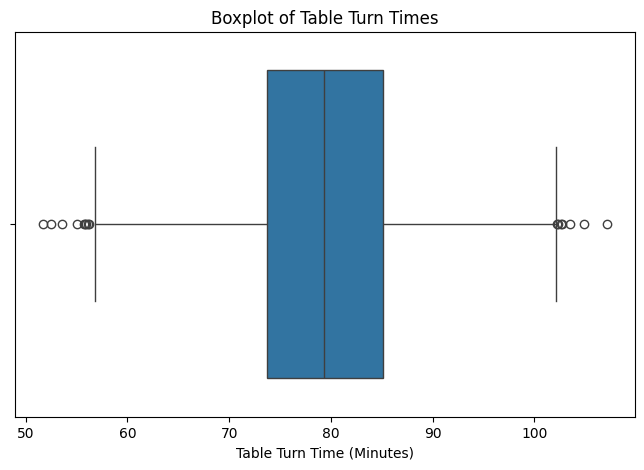

In [78]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['table_turn_time'])
plt.title('Boxplot of Table Turn Times')
plt.xlabel('Table Turn Time (Minutes)');


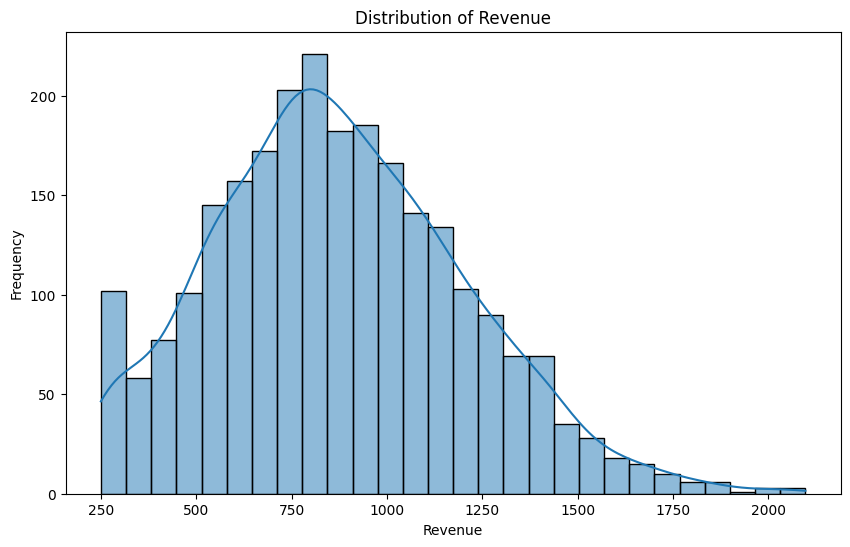

In [79]:
plt.figure(figsize=(10,6))
sns.histplot(df['revenue'],kde="true")
plt.title('Distribution of Revenue')
plt.xlabel('Revenue')
plt.ylabel('Frequency');


Customer satisfaction scores were generally concentrated around the restaurant’s average satisfaction level, suggesting guests were consistently moderately satisfied across most operational periods.

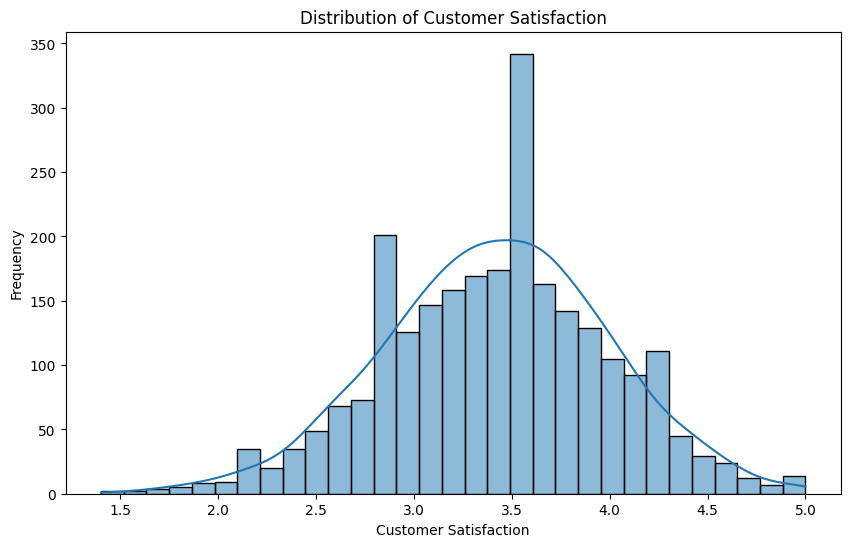

In [80]:
plt.figure(figsize=(10,6))
sns.histplot(df['customer_satisfaction'],kde='True')
plt.title('Distribution of Customer Satisfaction')
plt.xlabel('Customer Satisfaction')
plt.ylabel('Frequency');

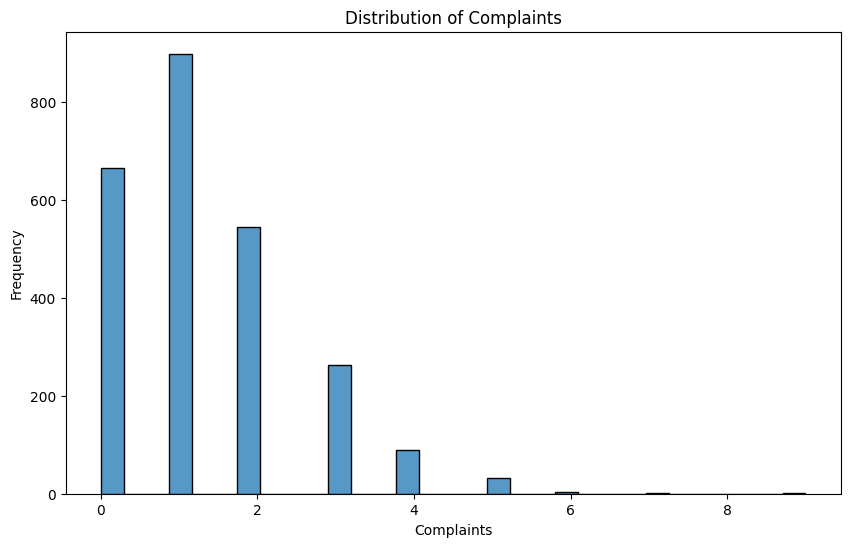

In [81]:
plt.figure(figsize=(10,6))
sns.histplot(df['complaints'])
plt.title('Distribution of Complaints')
plt.xlabel('Complaints')
plt.ylabel('Frequency');
#

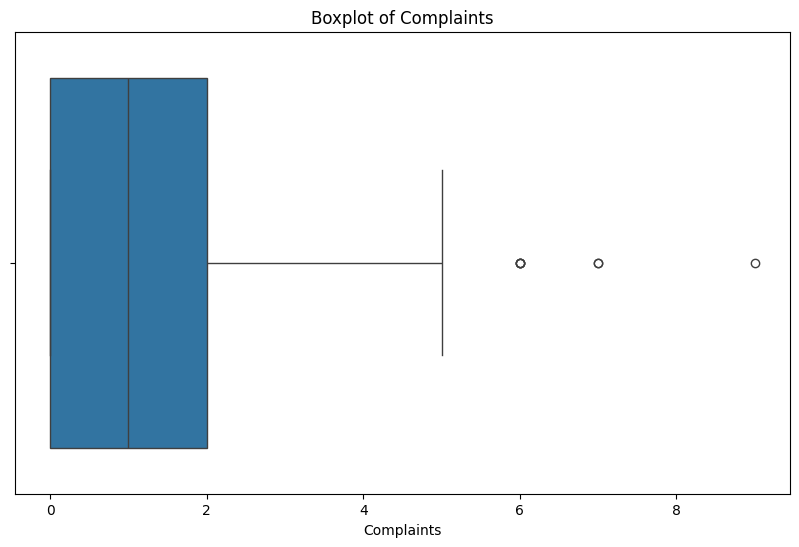

In [82]:
plt.figure(figsize=(10,6))
sns.boxplot(x=df['complaints'])
plt.title('Boxplot of Complaints')
plt.xlabel('Complaints');

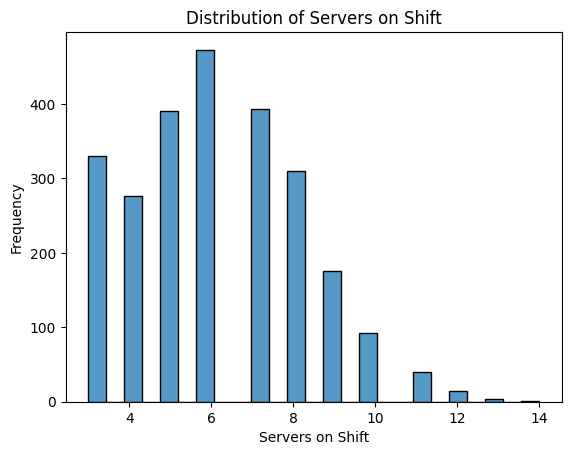

In [83]:

sns.histplot(df['servers_on_shift'])
plt.title('Distribution of Servers on Shift')
plt.xlabel('Servers on Shift')
plt.ylabel('Frequency');

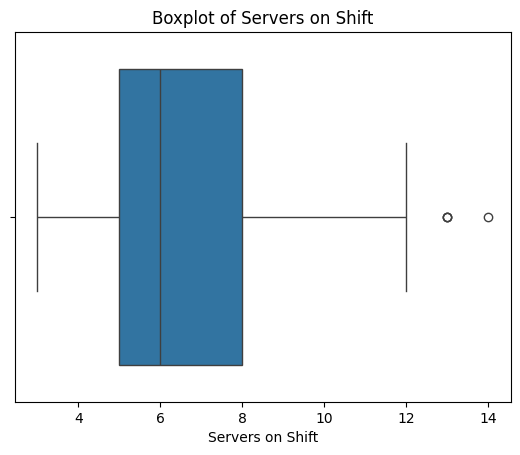

In [84]:
sns.boxplot(x=df['servers_on_shift'])
plt.title('Boxplot of Servers on Shift')
plt.xlabel('Servers on Shift');


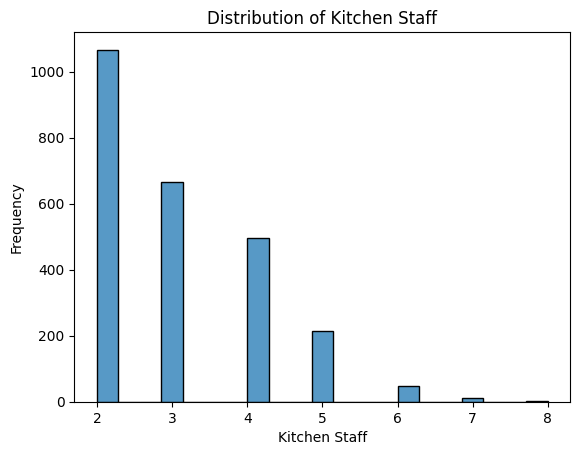

In [85]:
sns.histplot(df['kitchen_staff'])
plt.title('Distribution of Kitchen Staff')
plt.xlabel('Kitchen Staff')
plt.ylabel('Frequency');

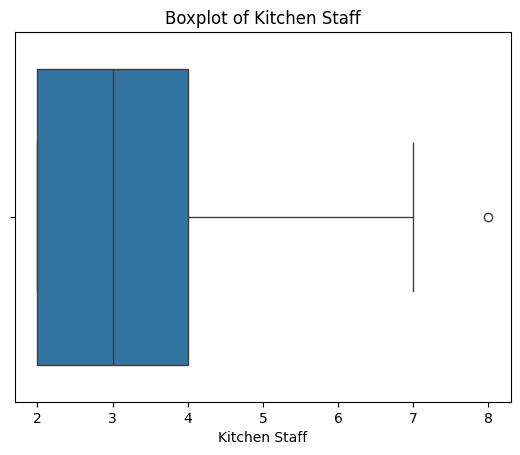

In [86]:
sns.boxplot(x=df['kitchen_staff'])
plt.title('Boxplot of Kitchen Staff')
plt.xlabel('Kitchen Staff');

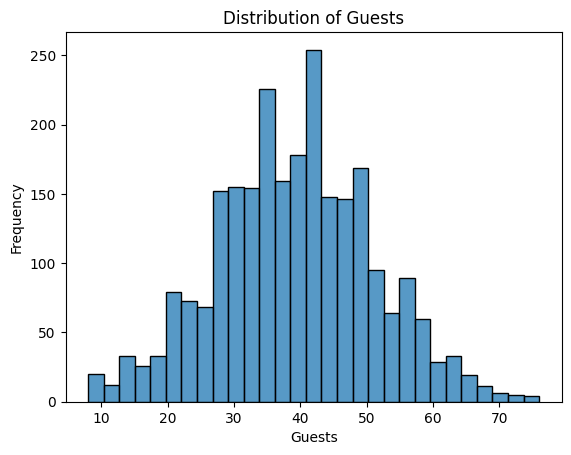

In [87]:
sns.histplot(df['guests'])
plt.title('Distribution of Guests')
plt.xlabel('Guests')
plt.ylabel('Frequency');

## Bivariate Analysis

Customer satisfaction appeared to decline as wait times increased, with a more noticeable drop occurring beyond approximately 20 minutes. This suggests the restaurant may benefit operationally from maintaining wait times below this threshold during higher-demand periods.

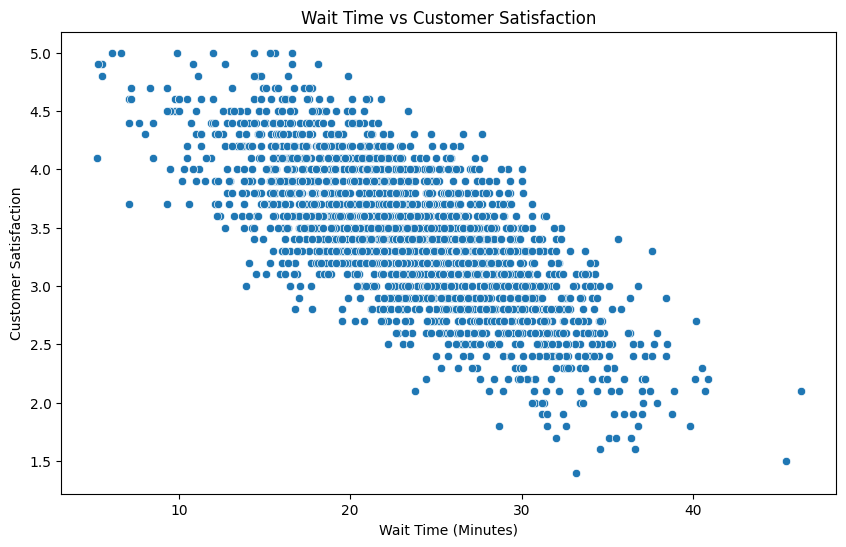

In [88]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='wait_time_minutes', y='customer_satisfaction')
plt.title('Wait Time vs Customer Satisfaction')
plt.xlabel('Wait Time (Minutes)')
plt.ylabel('Customer Satisfaction')
plt.show()

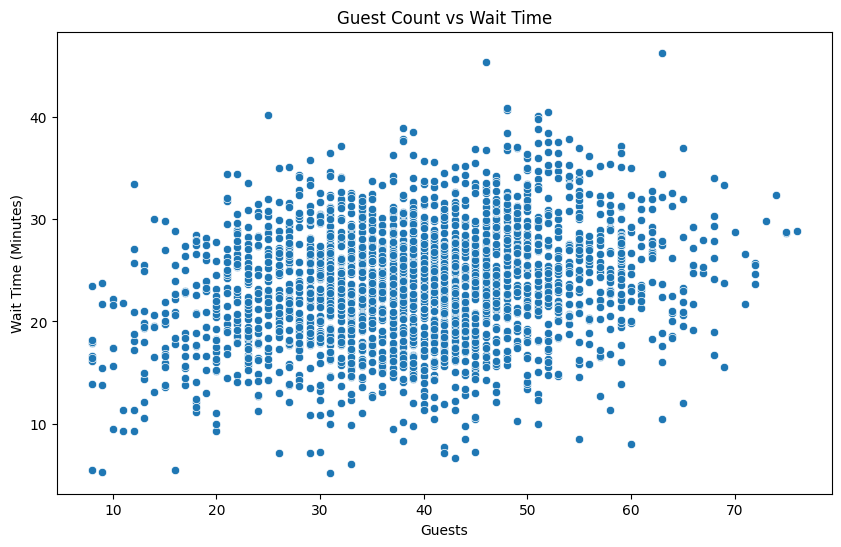

In [89]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='guests', y='wait_time_minutes')
plt.title('Guest Count vs Wait Time')
plt.xlabel('Guests')
plt.ylabel('Wait Time (Minutes)')
plt.show()

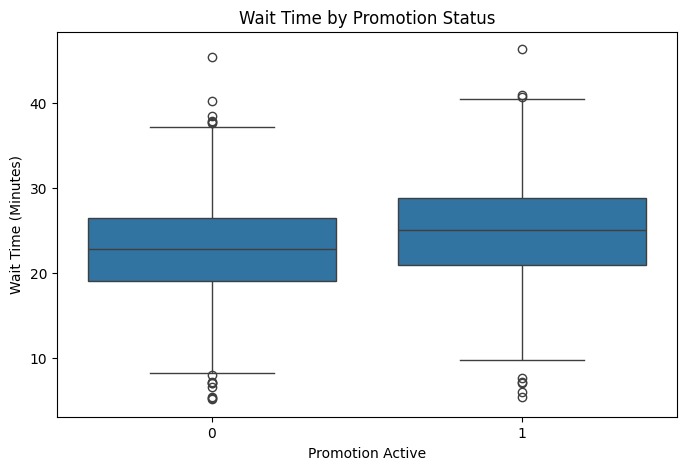

In [90]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='promo_active', y='wait_time_minutes')
plt.title('Wait Time by Promotion Status')
plt.xlabel('Promotion Active')
plt.ylabel('Wait Time (Minutes)')
plt.show()

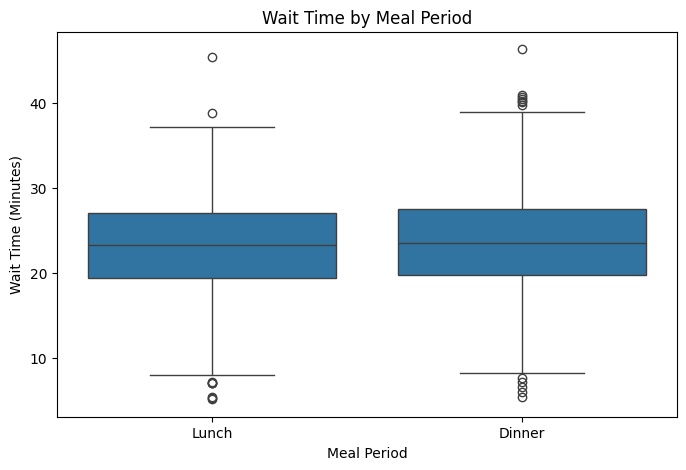

In [91]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='meal_period', y='wait_time_minutes')
plt.title('Wait Time by Meal Period')
plt.xlabel('Meal Period')
plt.ylabel('Wait Time (Minutes)')
plt.show()

## Feature Engineering

In [92]:
df['guests_per_server'] = df['guests'] / df['servers_on_shift']

df['guests_per_kitchen_staff'] = df['guests'] / df['kitchen_staff']

To better evaluate operational pressure, I created staffing load ratios: guests per server and guests per kitchen staff. These metrics are more meaningful than raw staffing counts because they compare staffing levels relative to demand.

## Operational Load Analysis


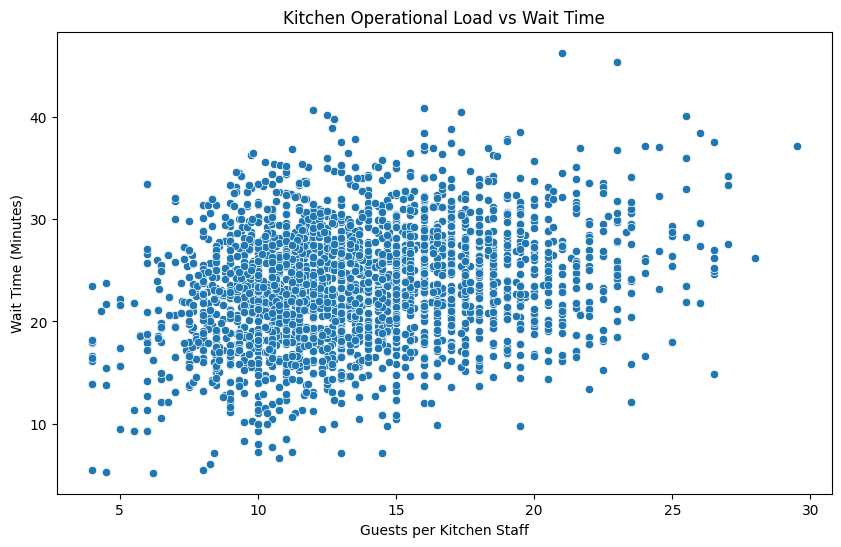

In [93]:
plt.figure(figsize=(10,6))

sns.scatterplot(data=df,
                x='guests_per_kitchen_staff',
                y='wait_time_minutes')

plt.title('Kitchen Operational Load vs Wait Time')
plt.xlabel('Guests per Kitchen Staff')
plt.ylabel('Wait Time (Minutes)')

plt.show()

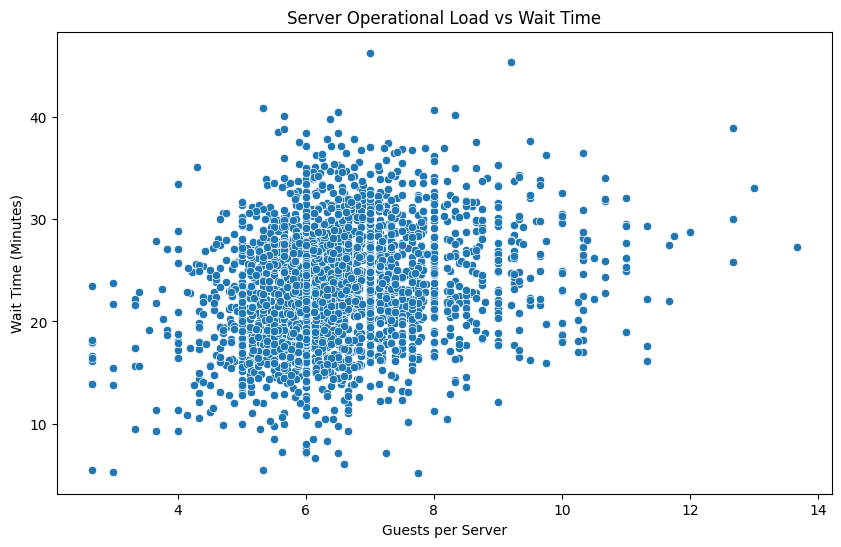

In [94]:
plt.figure(figsize=(10,6))

sns.scatterplot(data=df,
                x='guests_per_server',
                y='wait_time_minutes')

plt.title('Server Operational Load vs Wait Time')
plt.xlabel('Guests per Server')
plt.ylabel('Wait Time (Minutes)');

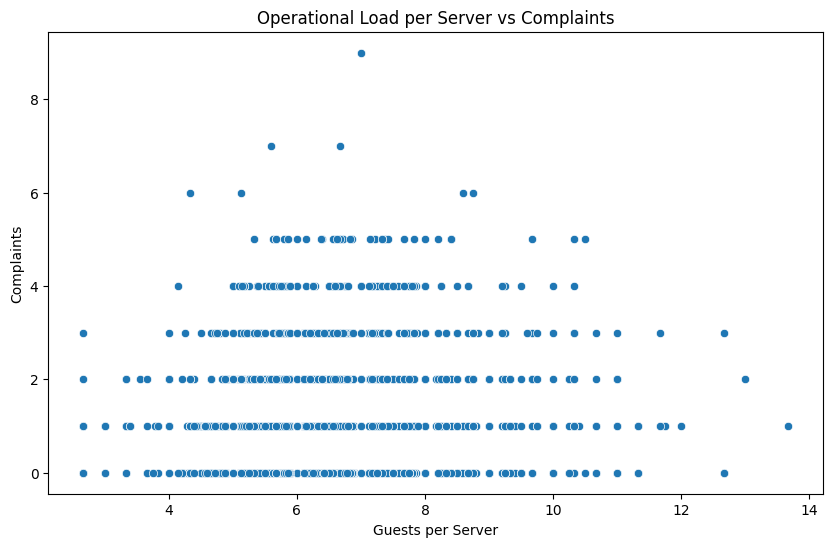

In [95]:
plt.figure(figsize=(10,6))

sns.scatterplot(data=df,
                x='guests_per_server',
                y='complaints')

plt.title('Operational Load per Server vs Complaints')
plt.xlabel('Guests per Server')
plt.ylabel('Complaints')

plt.show();

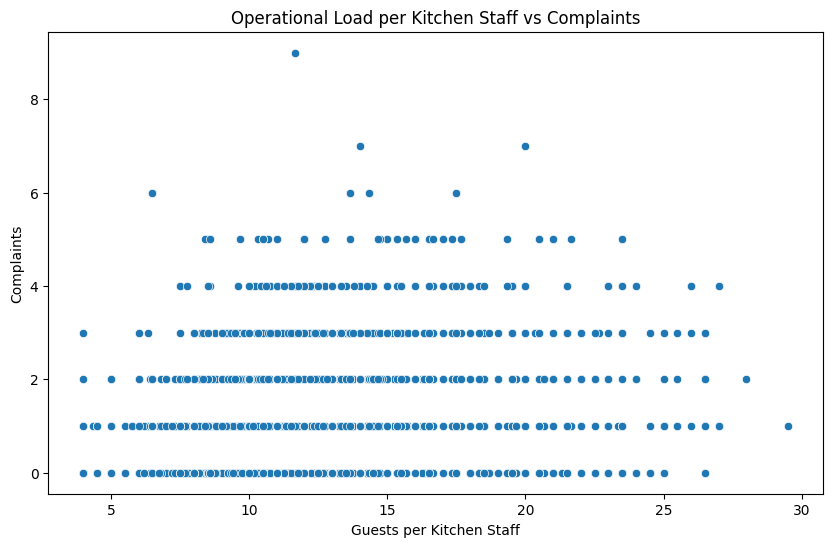

In [96]:
plt.figure(figsize=(10,6))

sns.scatterplot(data=df,
                x='guests_per_kitchen_staff',
                y='complaints')

plt.title('Operational Load per Kitchen Staff vs Complaints')
plt.xlabel('Guests per Kitchen Staff')
plt.ylabel('Complaints')

plt.show()

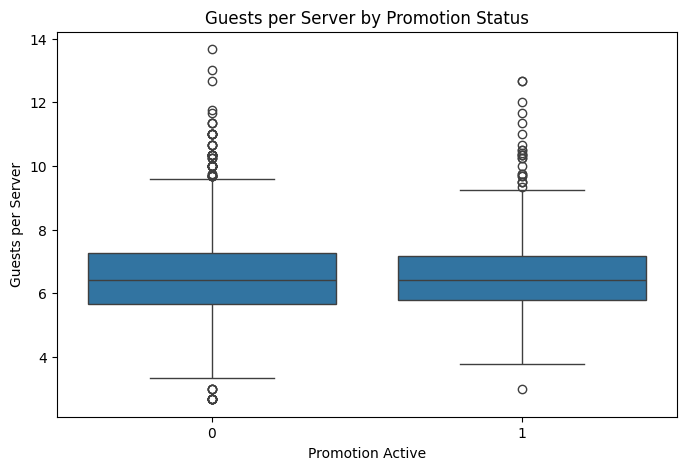

In [97]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df,
            x='promo_active',
            y='guests_per_server')

plt.title('Guests per Server by Promotion Status')
plt.xlabel('Promotion Active')
plt.ylabel('Guests per Server')

plt.show()

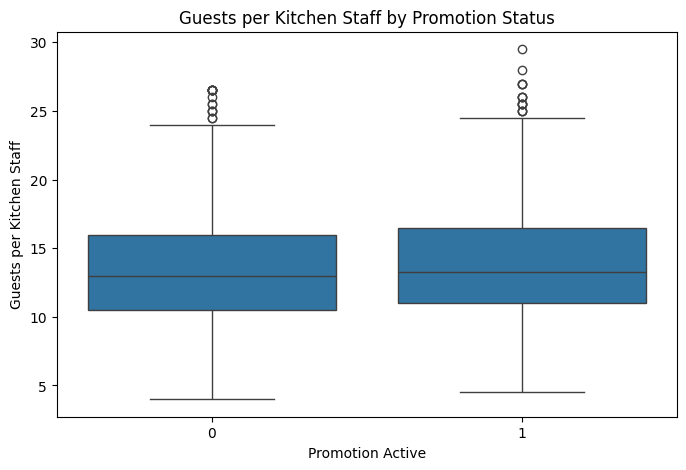

In [98]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df,
            x='promo_active',
            y='guests_per_kitchen_staff')
plt.title('Guests per Kitchen Staff by Promotion Status')
plt.xlabel('Promotion Active')
plt.ylabel('Guests per Kitchen Staff')
plt.show()

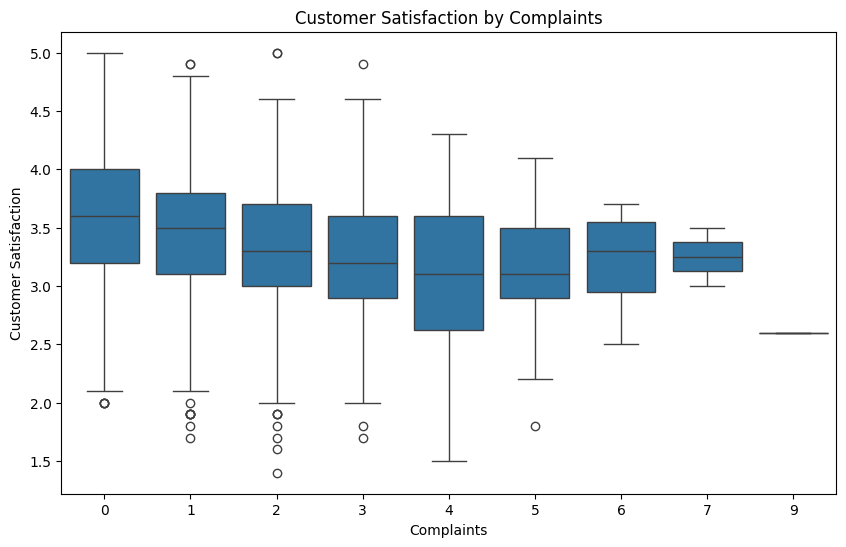

In [99]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x='complaints',y='customer_satisfaction')
plt.title('Customer Satisfaction by Complaints')
plt.xlabel('Complaints')
plt.ylabel('Customer Satisfaction')
plt.show()

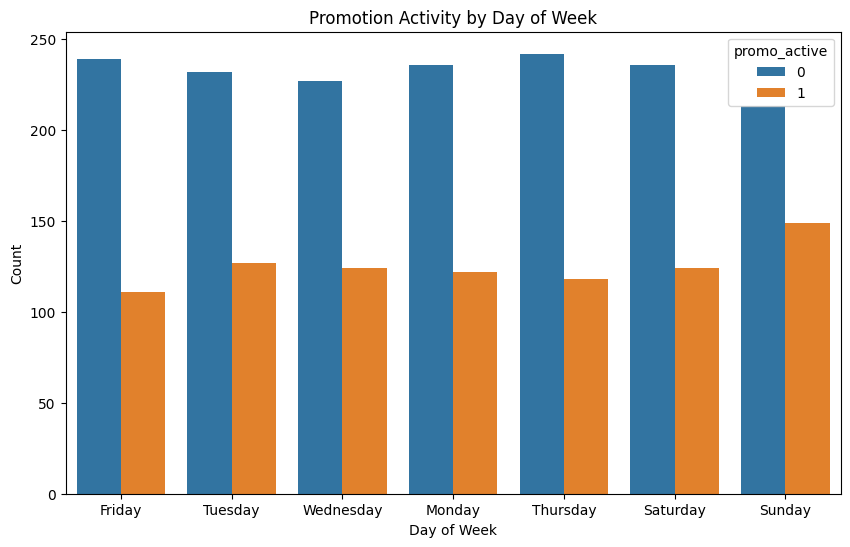

In [100]:
plt.figure(figsize=(10,6))

sns.countplot(data=df,
              x='day_of_week',
              hue='promo_active')

plt.title('Promotion Activity by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Count')

plt.show()

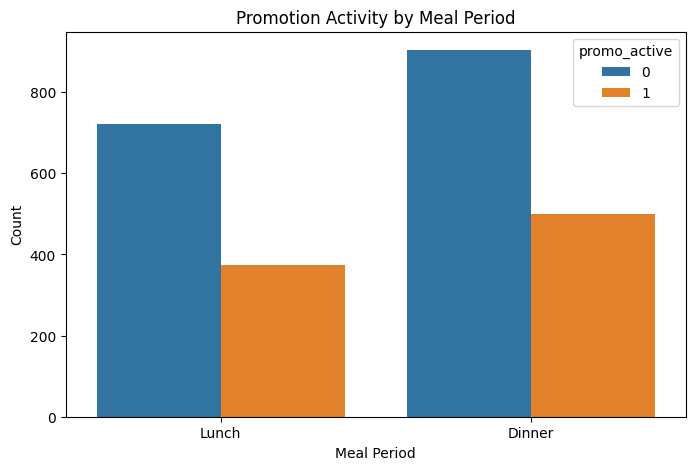

In [101]:
plt.figure(figsize=(8,5))

sns.countplot(data=df,
              x='meal_period',
              hue='promo_active')

plt.title('Promotion Activity by Meal Period')
plt.xlabel('Meal Period')
plt.ylabel('Count')

plt.show()

## Correlation Analysis

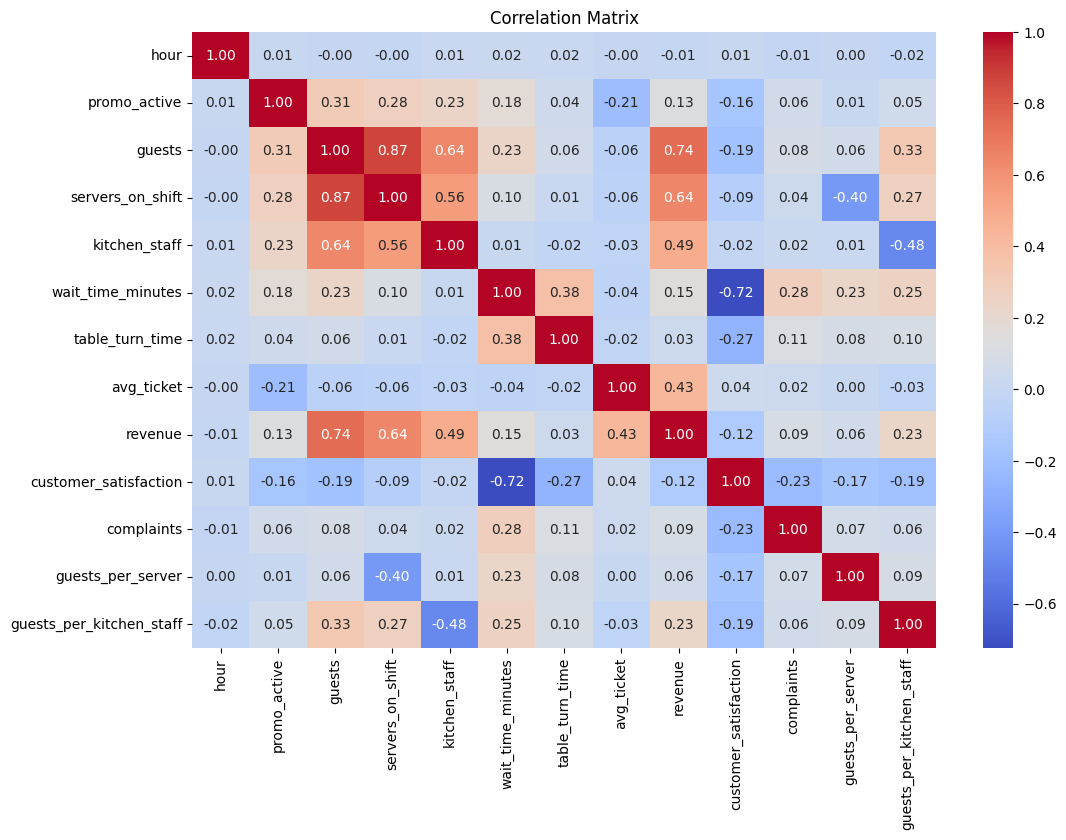

In [102]:
plt.figure(figsize=(12,8))

corr = df.corr(numeric_only=True)

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Correlation Matrix')

plt.show()

The correlation matrix helped validate several patterns from the exploratory analysis, including the negative relationship between wait time and customer satisfaction, as well as relationships between operational load, promotional activity, and revenue-related variables.

## Predictive Modeling

In [103]:
X = df[['wait_time_minutes',
        'table_turn_time',
        'guests',
        'promo_active',
        'avg_ticket',
        'complaints']]

y = df['customer_satisfaction']

To evaluate which operational factors were most associated with customer satisfaction, I built a Multiple Linear Regression model using wait time, table turn time, guest count, promotional activity, average ticket, and complaints as predictors. I then compared it to a Decision Tree Regressor to determine whether a nonlinear model improved performance.

In [104]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=1
)

In [105]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

In [106]:
y_pred = lr.predict(X_test)

In [107]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

MAE: 0.3152347217647891
RMSE: 0.3906083470894821
R2: 0.5644625581778642


In [108]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
})

coefficients

,Feature,Coefficient
0,wait_time_minutes,-0.071512
1,table_turn_time,0.000194
2,guests,-0.000194
3,promo_active,-0.025841
4,avg_ticket,0.000772
5,complaints,-0.015571


In [109]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=1)

dt.fit(X_train, y_train)

DecisionTreeRegressor(random_state=1)

The Linear Regression model provided interpretable coefficients and identified wait time as the strongest negative predictor of customer satisfaction.

In [110]:
y_pred_dt = dt.predict(X_test)

In [111]:
print("MAE:", mean_absolute_error(y_test, y_pred_dt))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dt)))
print("R2:", r2_score(y_test, y_pred_dt))
#

MAE: 0.4624
RMSE: 0.583506640921935
R2: 0.0280720692781824


The Decision Tree model performed worse than Linear Regression, with higher prediction error and lower explanatory power. Because Linear Regression performed better and provided clearer interpretability, it was selected as the final model for this analysis.

## Key Findings

1. Among all variables analyzed, wait time had the greatest negative association with customer satisfaction.  Customer satisfaction began to decline more rapidly when wait times exceeded approximately 20 minutes, indicating that this threshold may represent a practical operational benchmark for service perfromance.

2. Longer table turn times were also associated with lower customer satisfaction and increased complaints. The current average table turn time of approximately 80 minutes extends table occupancy, limiting seating availability and reducing overall throughput.

3. Customer satisfaction appeared to decline modestly during promotional periods. Promotional activity was concentrated during dinner service and on Sundays, and was associated with higher operational variability and lower average ticket values.

4. Potential operational stress points emerged when guest volume exceeded approximately 15 guests per kitchen staff member and 7 guests per server. Beyond these thresholds, wait times became significantly more variable.

5. Higher guest counts were associated with increased total revenue; however, average ticket values and customer satisfaction declined while operational strain increased. This suggests a potential tradeoff between revenue quantity and the quality of the guest experience.

## Recommendations

1. **Maintain Average Wait Times Below 20 Minutes**
Customer satisfaction declined more rapidly when wait times exceeded approximately 20 minutes. Management should prioritize operational changes that consistently keep wait times below this threshold, particularly during peak demand periods. Potential actions include adjusting staffing levels, improving kitchen throughput, and monitoring real-time service performance to identify emerging bottlenecks before guest experience deteriorates.

2. **Reduce Average Table Turn Times Through Service & Kitchen Process Improvements**.The restaurant’s average table turn time of approximately 80 minutes was associated with declining customer satisfaction and higher complaint levels. Increasing staffing during peak periods and streamlining service processes may help reduce table occupancy durations and improve overall throughput.In addition to targeted staffing adjustments, management may be able to reduce extended table turn times by streamlining kitchen workflows, improving table management procedures, and simplifying menu items that create production bottlenecks. These process improvements could increase throughput without materially increasing labor costs.


3. **Shift Promotional Efforts Toward Lower-Demand Periods Such As Lunch**  Promotional activity is currently concentrated during Sunday and dinner service, when customer demand is already highest. Reallocating promotional efforts to lower-demand periods, such as lunch, may provide additional revenue opportunities while reducing operational strain during peak service periods. This approach could improve execution, maintain customer satisfaction, and support more efficient use of labor and kitchen capacity.


4. **Monitor Operational Capacity Thresholds:** Customer satisfaction declined and wait times became more variable when staffing levels exceeded approximately 15 guests per kitchen staff member and 7 guests per server. Management should monitor guest counts relative to staffing levels and consider pacing seating or adjusting staffing when these thresholds are approached to reduce operational bottlenecks and maintain service consistency.


5. **Focus On Higher-Quality Revenue Rather Than Simply Maximizing Traffic.**
While higher guest counts were associated with increased total revenue, average ticket values and customer satisfaction declined as operational strain increased. At the same time, customer satisfaction remained relatively stable overall, suggesting the restaurant may have a loyal customer base. Rather than relying primarily on promotions to drive additional traffic, management may benefit from strategies designed to increase revenue per guest, such as menu innovation, targeted loyalty rewards, and exclusive events such as beer pairing dinners.

## Future Opportunities

Future analysis could explore revenue quality, customer retention behavior, promotion effectiveness by customer segment, and wait time forecasting by hour and day. Additional data such as party size, menu mix, reservation volume, kitchen ticket times, and repeat customer behavior would allow for deeper operational analysis.